<h1 style="color:red;">EDA on Retail Sales Data</h1>

## Load dataset

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('retail_sales_dataset.csv')

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


## Perform initial inspection

In [4]:
df.shape

(1000, 9)

In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Descriptive statistics

In [8]:
df[['Age','Quantity','Price per Unit','Total Amount']].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


In [9]:
df[['Age','Quantity','Price per Unit','Total Amount']].mode()

,Age,Quantity,Price per Unit,Total Amount
0,43,4.0,50.0,50.0
1,64,NaN,NaN,NaN


**Observation:** The average transaction amount is 456, but the median is only 135, so a few high-value purchases pull the average up. The average customer age is about 41, and the most common quantity per purchase is 4.

##  Time series analysis

In [10]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 90.4 KB


In [12]:
df['Month']=df['Date'].dt.month

In [13]:
df['Date'].dt.year.value_counts()

Date
2023    998
2024      2
Name: count, dtype: int64

In [14]:
df[['Date','Month']].head()

,Date,Month
0,2023-11-24,11
1,2023-02-27,2
2,2023-01-13,1
3,2023-05-21,5
4,2023-05-06,5


In [15]:
df['Quarter']=df['Date'].dt.quarter

In [16]:
df[['Date','Quarter']].head()

,Date,Quarter
0,2023-11-24,4
1,2023-02-27,1
2,2023-01-13,1
3,2023-05-21,2
4,2023-05-06,2


In [17]:
df_2023 = df[df['Date'].dt.year == 2023]

monthly_sales = df_2023.groupby('Month')['Total Amount'].sum()
monthly_sales

Month
1     35450
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

In [18]:
quarterly_sales = df_2023.groupby('Quarter')['Total Amount'].sum()
quarterly_sales

Quarter
1    108500
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

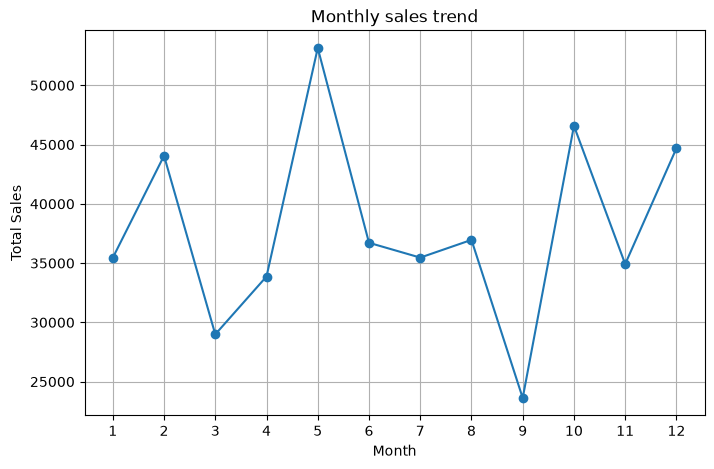

In [20]:
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')
plt.title('Monthly sales trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

### Observation

Monthly sales fluctuate throughout the year. May recorded the highest monthly sales of 53,150, while September recorded the lowest at 23,620. This indicates that customer purchasing activity varies considerably across months.

**Note:** Two transactions dated in 2024 were excluded so the monthly and quarterly trends cover 2023 only.

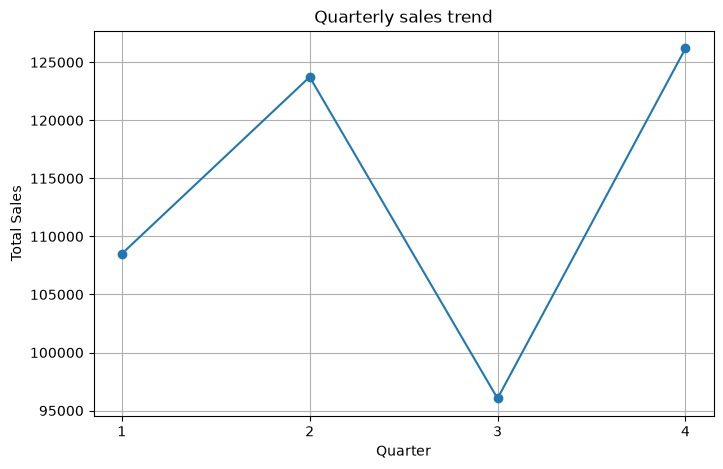

In [21]:
plt.figure(figsize=(8,5))
plt.plot(quarterly_sales.index,
         quarterly_sales.values,
         marker='o')
plt.title('Quarterly sales trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(range(1,5))
plt.grid(True)
plt.show()

### Observation

Quarter 4 recorded the highest sales at 126,190, followed by Quarter 2 with 123,735. Quarter 3 recorded the lowest sales at 96,045. This indicates that sales performance varies across quarters, with stronger sales activity toward the end of the year.

##  Customer demographics analysis

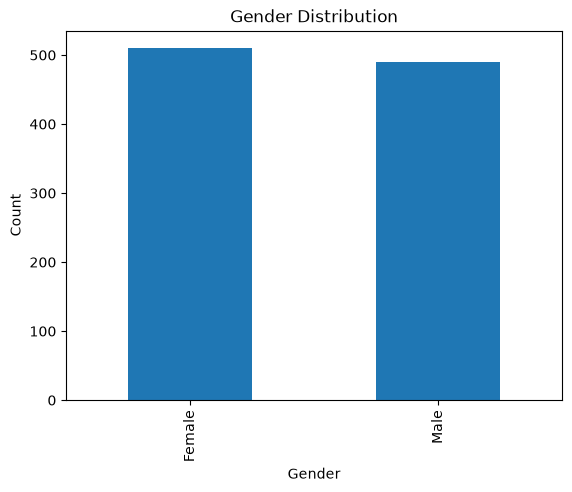

In [22]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Observation

The customer base is fairly balanced by gender, with female customers representing a slightly larger share than male customers. This indicates that both genders form a substantial part of the customer base.

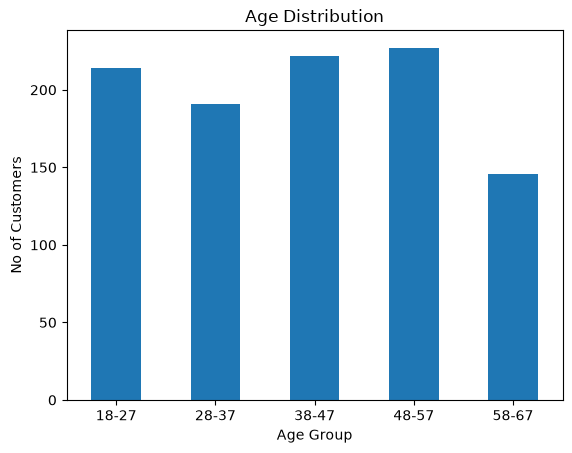

In [23]:
age_group=pd.cut(df['Age'],
                  bins=(17,27,37,47,57,67),
                  labels=('18-27','28-37','38-47','48-57','58-67'))
age_group.value_counts().sort_index().plot(kind='bar')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('No of Customers')
plt.xticks(rotation=0)
plt.show()

### Observation

Customers are distributed across all five age groups. The 48–57 age group has the highest number of customers, while the 58–67 age group has the lowest representation. This indicates that the retail business attracts customers across a broad range of ages.

## Product analysis

The dataset does not contain individual product names or product IDs. Therefore, a Top 10 Best-Selling Products analysis cannot be performed. Product Category has been used as the closest available level of analysis.

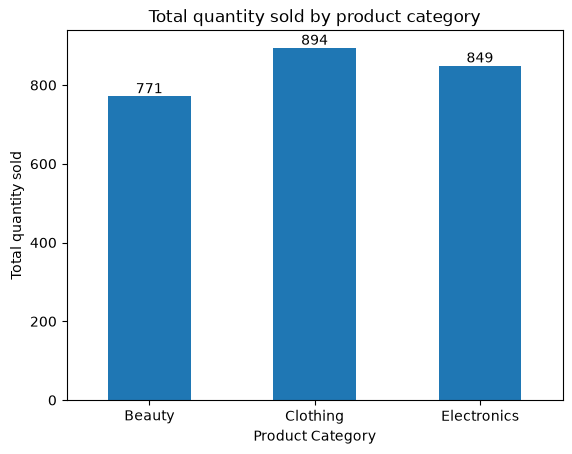

In [24]:
ax = df.groupby('Product Category')['Quantity'].sum().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Total quantity sold by product category')
plt.xlabel('Product Category')
plt.ylabel('Total quantity sold')
plt.xticks(rotation=0)
plt.show()

### Observation

Clothing has the highest total quantity sold with 894 units, followed by Electronics with 849 units. Beauty has the lowest quantity sold with 771 units. This indicates that Clothing has the highest sales volume among the three product categories.

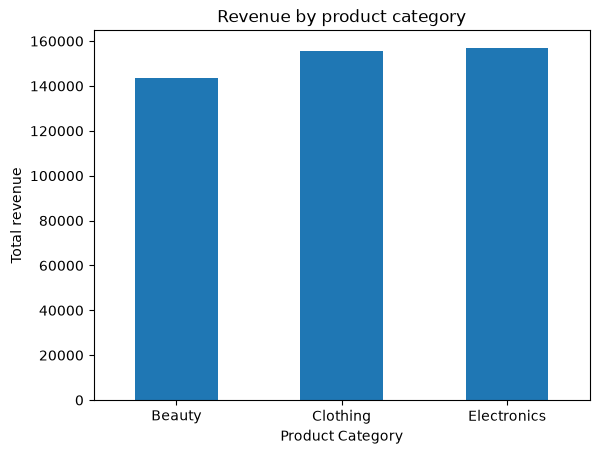

In [25]:
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')
plt.title('Revenue by product category')
plt.xlabel('Product Category')
plt.ylabel('Total revenue')
plt.xticks(rotation=0)
plt.show()

### Observation
Electronics generated the highest revenue, followed closely by Clothing. Beauty generated the lowest revenue. This suggests that although Clothing sold the highest quantity, Electronics products contributed more revenue per sale.

## Heatmap

In [26]:
corr=df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
corr

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


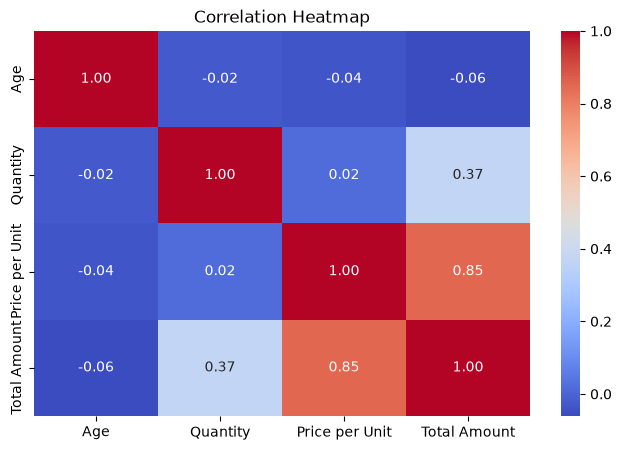

In [27]:
plt.figure(figsize=(8,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Observation

The heatmap shows a strong positive correlation between Price per Unit and Total Amount (0.85), while Quantity and Total Amount have a moderate positive correlation (0.37). Age has very weak correlations with Quantity, Price per Unit, and Total Amount, indicating little linear relationship between customer age and these transaction variables.

## Average spending by age group

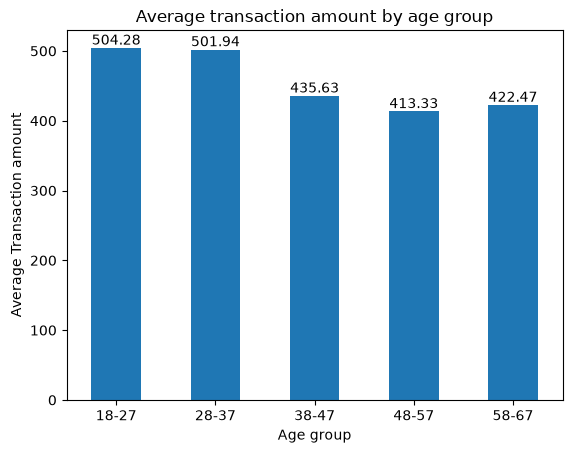

In [28]:
ax = df.groupby(age_group, observed=True)['Total Amount'].mean().plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.title('Average transaction amount by age group')
plt.xlabel('Age group')
plt.ylabel('Average Transaction amount')
plt.xticks(rotation=0)
plt.show()

### Observation

The 18–27 age group has the highest average transaction amount at 504.28, closely followed by the 28–37 group at 501.94. The 48–57 group has the lowest average transaction amount at 413.33. Although the 48–57 group has the largest customer representation, it does not have the highest average spending per transaction.

## Conclusion

The exploratory data analysis revealed several patterns in customer purchasing behaviour and product performance.

### Key Findings

- Clothing recorded the highest total quantity sold, with 894 units.
- The 18–27 age group had the highest average transaction amount at 504.28.
- Price per Unit and Total Amount showed a strong positive correlation of 0.85.
- The customer base was relatively balanced by gender.
- The 48–57 age group had the largest customer representation, but it did not have the highest average transaction amount.
- Sales peaked in Quarter 4 and in May, and were lowest in September.

### Business Recommendations

1. **Prioritize Clothing inventory and promotions:** Clothing had the highest sales quantity, so inventory levels and promotional activities can be adjusted to maintain availability and capitalize on demand.

2. **Target younger customer groups:** Customers aged 18–37 recorded the highest average transaction amounts. The business could develop targeted promotions, bundles, and campaigns for these age groups.

3. **Monitor pricing and high-value transactions:** The strong positive correlation between Price per Unit and Total Amount suggests that higher-priced purchases contribute substantially to transaction value. The business can evaluate premium products and bundles while monitoring demand.

4. **Plan campaigns around seasonal patterns:** Quarter 4 had the highest sales (126,190) and May was the best month (53,150), so stock levels and marketing should be strongest in these periods. September (23,620) and Quarter 3 (96,045) were the weakest, so targeted offers in these months could lift sales.